In [1]:
import yaml
import torch
import numpy as np
from einops import rearrange
from matplotlib import pyplot as plt
from typing import Sequence

### Visualize Patch Tumor Distribution

In [2]:
rootdir = '/home/ca550013/Master-Thesis/Projects/BraTS3DDiff'

In [3]:
from src.datasets.patch_tumor_classify_diffusion_datamodule_new_new import BraTSDataModule

In [4]:
with open(f"{rootdir}/configs/data/brats23_patch_tumor_classify_diffusion_new.yaml") as f:
    cfg = yaml.safe_load(f)
cfg.pop('_target_')
cfg['data_dir'] = f"{rootdir}/data/BraTS-Data/BraTS2023-GLI"
cfg['batch_size'] = 1
cfg['patch_sizes'] = [16, 32]
datamodule = BraTSDataModule(**cfg)

train_data = datamodule.data_train
test_data = datamodule.data_test
val_data = datamodule.data_val


/home/ca550013/Miniconda3-New/envs/bratseg/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [5]:
data = val_data.__getitem__(5)
data.keys()

dict_keys(['image', 'mask', 'mask_labels', 'foreground_start_coord', 'foreground_end_coord', 'patch_tumor_vol_fracs', 'patch_tumor_labels'])

In [6]:
data['patch_tumor_vol_fracs']['32'].shape

NameError: name 'data' is not defined

Plotting tools

In [5]:
from matplotlib import pyplot as plt

def compute_histogram(patch_vol_fracs, nbins=10, res=16):
    '''
    Compute histogram of tumor vol fracs of patches in an image.
    Count zero vol patches and non zero patches separately
    '''
    #patch_vol_fracs: (1,8,8,8) tensor
    patch_vol_fracs = patch_vol_fracs.view(1, -1)

    non_zero_vol_fracs = patch_vol_fracs[patch_vol_fracs > 0]
    hist = torch.histogram(input=non_zero_vol_fracs, bins=nbins, range=(non_zero_vol_fracs.min().item(),1))

    num_zero_patches = (patch_vol_fracs == 0).sum().item()
    bin_counts = torch.cat((torch.tensor([num_zero_patches]), hist.hist)).numpy()
    bin_edges = torch.cat((torch.tensor([0.0]), hist.bin_edges)).numpy()
    #print('bin_edges', bin_edges)
    bin_labels = ["0 (zero)"] + [
        f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(1, len(bin_edges) - 1)
    ]

    num_non_zero_patches = non_zero_vol_fracs.shape[0]
    counts = np.array([num_zero_patches, num_non_zero_patches])
    labels = ['Zero Vol Patches', 'Non-Zero Vol Patches']

    return {f'hist_{res}':(bin_counts, bin_labels), f'hist2_{res}':(counts, labels)}


def plot_hist(ax, bin_counts, bin_labels, res=16):
    ax.bar(range(len(bin_counts)), bin_counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_xlabel("Volume Fractions")
    ax.set_ylabel("Number of Patches")
    ax.set_title(f"Histogram of Patch Tumor Volume Fractions\nPatch size={res}")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax

def plot_hist_binary(ax, counts, labels, res=16):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Number of Patches")
    ax.set_title(f"Distribution of non-zero and zero volume patches\nPatch size={res}")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax

def transform_imgs(data: dict, depth:int=None, label_regions=['WT','TC', 'ET'], patch_sizes:list=None, key=''):
    #Transforms a dict of 3D images to 2D
    new_data = {}
    img_key, label_key, label_key_ = [f"{key}{x}" for x in ['image', 'mask', "mask_labels"]]
    
    image = data[img_key]
    if depth is None:
        depth = image.shape[-1] // 2
    new_data[img_key] = image[0,:,:,depth]

    new_data[label_key_] = data[label_key_][0,:,:,depth]

    if label_regions is not None:
        label = data[label_key][:,:,:,depth]
        labels = {f"{key}label_{label_regions[i]}": label[i,:,:] for i in range(len(label_regions))}
        new_data.update(labels)

    if ('patch_tumor_labels' in data.keys()) and (patch_sizes is not None):
        for patch_size in patch_sizes:
            patch_labels = data['patch_tumor_labels'][patch_size]
            new_data[f'patch_labels_{patch_size}'] = patch_labels[0,:,:,patch_labels.shape[-1] // 2]

    if ('patch_tumor_vol_fracs' in data.keys()) and (patch_sizes is not None):
        for patch_size in patch_sizes:
            patch_labels = data['patch_tumor_vol_fracs'][patch_size]
            new_data[f'patch_vol_frac_{patch_size}'] = patch_labels[0,:,:,patch_labels.shape[-1] // 2]

    return new_data

def imshows(ims: list[dict]):
    nrow = len(ims)
    ncol = len(ims[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 5), facecolor="white")
    for i, im_dict in enumerate(ims):
        for j, (title, im) in enumerate(im_dict.items()):
            if isinstance(im, torch.Tensor):
                im = im.detach().cpu().numpy()
            if len(ims) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            #ax.grid(snap=False)
            if title.startswith('hist_'):
                res = title.split('_')[-1]
                ax = plot_hist(ax, im[0], im[1], res=res)
            elif title.startswith('hist2_'):
                res = title.split('_')[-1]
                ax = plot_hist_binary(ax, im[0], im[1], res=res)
            else:
                ax.set_title(f"{title}\n{im.shape}")
                im_show = ax.imshow(im)
                fig.colorbar(im_show, ax=ax)
    plt.tight_layout()


In [ ]:
to_imshow = []
for idx in np.random.randint(0, len(val_data), size=2):
    data_ = val_data.__getitem__(idx)
    data_.pop('patch_tumor_labels')
    hist_16 = compute_histogram(data_['patch_tumor_vol_fracs']['16'], res=16)
    hist_32 = compute_histogram(data_['patch_tumor_vol_fracs']['32'], res=32)
    data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
    data_1.update(hist_16)
    data_1.update(hist_32)

    to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
to_imshow = []
idx = 212

hist_16 = compute_histogram(data_['patch_tumor_vol_fracs']['16'], res=16)
hist_32 = compute_histogram(data_['patch_tumor_vol_fracs']['32'], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

Compute patch tumor vol distributions of all images in dataset \
And compute some statistics


In [6]:

hist_data = {'hist_16':[], 'hist2_16':[], 'hist_32':[], 'hist2_32':[]}
patch_tumor_vol_fracs = {'16':[], '32': []}
for idx in range(len(val_data)):
    data = val_data.__getitem__(idx)
    patch_tumor_vol_fracs['16'].append(data['patch_tumor_vol_fracs']['16'])
    hist_16 = compute_histogram(data['patch_tumor_vol_fracs']['16'], res=16)
    hist_data['hist_16'].append(hist_16['hist_16'][0])
    hist_data['hist2_16'].append(hist_16['hist2_16'][0])
    patch_tumor_vol_fracs['32'].append(data['patch_tumor_vol_fracs']['32'])
    hist_32 = compute_histogram(data['patch_tumor_vol_fracs']['32'], res=32)
    hist_data['hist_32'].append(hist_32['hist_32'][0])
    hist_data['hist2_32'].append(hist_32['hist2_32'][0])


mean_hist = {}
median_hist = {}
max_hist = {}
min_hist = {}

for key in hist_data.keys():
    hist_data[key] = np.array(hist_data[key])
    mean_hist[key] = np.mean(hist_data[key], axis=0)
    median_hist[key] = np.median(hist_data[key], axis=0)
    max_hist[key] = np.max(hist_data[key], axis=0)
    min_hist[key] = np.min(hist_data[key], axis=0)

print('Mean Statistics')
print(mean_hist)
print('Median Statistics')
print(median_hist)
print('Max Statistics')
print(max_hist)
print('Min Statistics')
print(min_hist)


Mean Statistics
{'hist_16': array([445.28076  ,  25.988462 ,   8.134615 ,   5.623077 ,   4.173077 ,
         3.623077 ,   3.4307692,   3.0423076,   2.7346153,   3.0423076,
         6.9269233], dtype=float32), 'hist2_16': array([445.28076923,  66.71923077]), 'hist_32': array([47.965385  ,  9.019231  ,  2.2576923 ,  1.3461539 ,  0.96153843,
        0.85384613,  0.5846154 ,  0.3923077 ,  0.26923078,  0.20384616,
        0.14615385], dtype=float32), 'hist2_32': array([47.96538462, 16.03461538])}
Median Statistics
{'hist_16': array([446.5,  25. ,   8. ,   5. ,   4. ,   3. ,   3. ,   2.5,   2. ,
         3. ,   5. ], dtype=float32), 'hist2_16': array([446.5,  65.5]), 'hist_32': array([48.,  9.,  2.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.],
      dtype=float32), 'hist2_32': array([48., 16.])}
Max Statistics
{'hist_16': array([500., 109.,  31.,  26.,  15.,  14.,  10.,  12.,  11.,  11.,  29.],
      dtype=float32), 'hist2_16': array([500, 210]), 'hist_32': array([62., 35.,  9.,  5.,  4.,  5.,  

### Observation:
<ins>16x16x16 patches (n=512):</ins> \
On **average**, there are 445 non-tumor patches and 67 tumor patches \
The **maximum** of tumor patches found in an image is 213

<ins>32x32x32 patches (n=64):</ins> \
On **average**, there are 48 non-tumor patches and 16 tumor patches \
The **maximum** of tumor patches found in an image is 48

### Patch Selection during Training

##### Diverse strategy: Biased towards tumor patches+All samples have a non-zero prob of getting selected
Sample C patches from N patches based on their weights. Add a small weight to Non-tumor patches so that have a non-zero probability of getting selected. Mix of weighted+uniform sampling to inrease diversity?


In [8]:
#Check number of images for which there are more than N tumor patches
key = 'hist2_16'
N=150
num_imgs = (hist_data[key][:,1] > N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data[key][:,1] >= N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data[key][i])


num number of images for which there are more than 150 tumor patches = 3
Image indices = [128 212 226]
Non-Tumor vs Tumor Patch counts of these images:
 [[344 168]
 [302 210]
 [358 154]]


In [ ]:
#Filter images wrt numof tumor patches
N=30
num_imgs = (hist_data['hist2_32'][:,1] == N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_32'][:,1] == N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_32'][i])

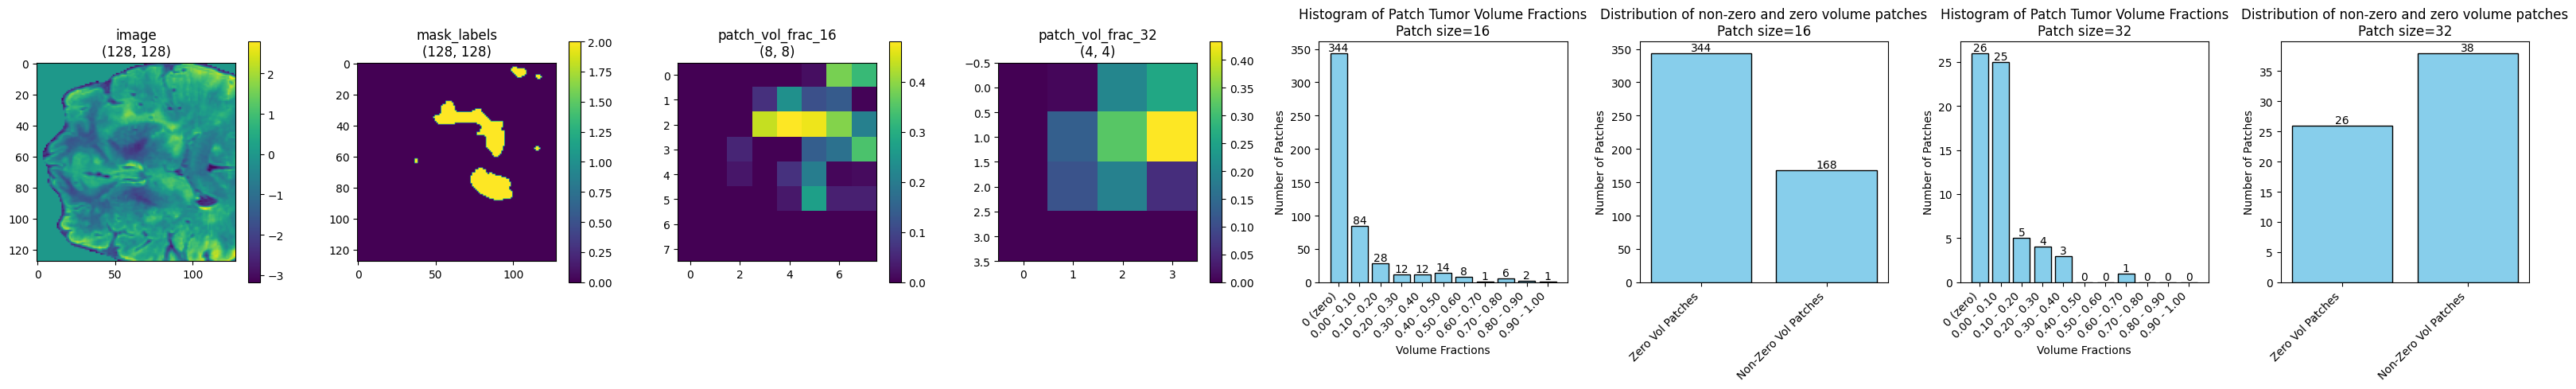

In [9]:
#Visualize these images
idx = 128 
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
#Visualize these images
idx = 212
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
idx = 212
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
all_patch_vols=torch.sort(all_patch_vols).values
print('All patches vol fracs sorted' ,all_patch_vols)
print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
all_patch_vols=all_patch_vols.squeeze(dim=0)

#### Patch Sampling
- Sampling should be biased towards tumor patches, and patches with higher tumor vols
- Sampling strategy should also cover the entire space of patches, ie mix of tumor and non tumor patches \
        No patch should go unseen. Model should see all the patches at least once during training

Idea: Add a small weight *eps* to all the patches so that the non-tumor patches also have > 0 probability of getting sampled \
*Higher the added weight, closer the sampling gets to uniform sampling*

wt of a patch = patch_tumor_vol_frac + eps

*eps scheduling*: Instead of adding a fixed weight, add **higher** weights in the **beginning** of training, so that model sees both tumor and non-tumor patches; \
As training progresses, **decreases** the added weights, so that the sampling becomes more biased towards the tumor patches

#### Comparison between different different values of eps, and fixed / dynamic eps
Goal: 
- Good patch coverage, ie after sampling for N rounds, all patches should be seen, and, 
- Biased sampling, ie Patches with higher tumor vols should be selected more often

Validation scheme:
Sample 32 out of 64 patches of an image N times, and after N rounds, count how many times each patch was sampled 

The patch distribution should be biased towards higher tumor vol patches, moreover,  non-tumor patches should also have non-zero counts. 

To see which sampling strategy captures both of these characteristics, compute similarity between the evaluated patch counts distribution and a baseline uniform and weighted patch distribution



In [203]:
#Filter images wrt numof tumor patches
N=32
num_imgs = (hist_data['hist2_32'][:,1] == N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_32'][:,1] == N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_32'][i])

num number of images for which there are more than 32 tumor patches = 2
Image indices = [ 82 128]
Non-Tumor vs Tumor Patch counts of these images:
 [[32 32]
 [32 32]]


Processing image 128
Non-Tumor and Tumor Patch Counts [344 168]
All patches vol fracs sorted metatensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 3.0518e-04, 4.2725e-04, 4.5776e-04, 1.3733e-03,
         2.1667e-03, 2.1667e-03, 2.2278e-03, 2.4414e-03, 8.4534e-03, 9.0942e-03,
         1.2299e-02, 1.4771e-02, 1.7242e-02, 1.8646e-02, 2.1515e-02, 2.3987e-02,
         3.1067e-02, 4.2328e-02, 5.8319e-02, 7.3700e-02, 7.7148e-02, 7.9132e-02,
         8.1573e-02, 8.7402e-02, 9.0698e-02, 1.1554e-01, 1.3144e-01, 1.4899e-01,
         1.8344e-01, 1.9113e-01, 2.0578e-01, 2.0880e-01, 2.5818e-01, 2.6080e-01,
         3.2495e-01, 3.3200e-01, 3.5034e-01, 6.0434e-01]])
metatensor([[ 0, 26],
        [ 0,

/home/ca550013/Miniconda3-New/envs/bratseg/lib/python3.10/site-packages/torch/nn/functional.py:2994: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Processing image 206
Non-Tumor and Tumor Patch Counts [404 108]
All patches vol fracs sorted metatensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 9.1553e-05, 1.5259e-04, 1.8311e-04,
         2.4414e-04, 3.0518e-04, 4.8828e-04, 1.0376e-03, 1.2817e-03, 1.7395e-03,
         2.1362e-03, 2.5940e-03, 1.1444e-02, 1.3000e-02, 2.3438e-02, 2.5299e-02,
         3.4576e-02, 4.5471e-02, 4.8431e-02, 5.0140e-02, 5.4901e-02, 8.1635e-02,
         8.5571e-02, 9.7260e-02, 1.5680e-01, 1.6418e-01, 2.2058e-01, 2.6880e-01,
         4.0836e-01, 5.3796e-01, 6.6248e-01, 7.7338e-01]])
metatensor([[ 0, 33],
        [ 0,

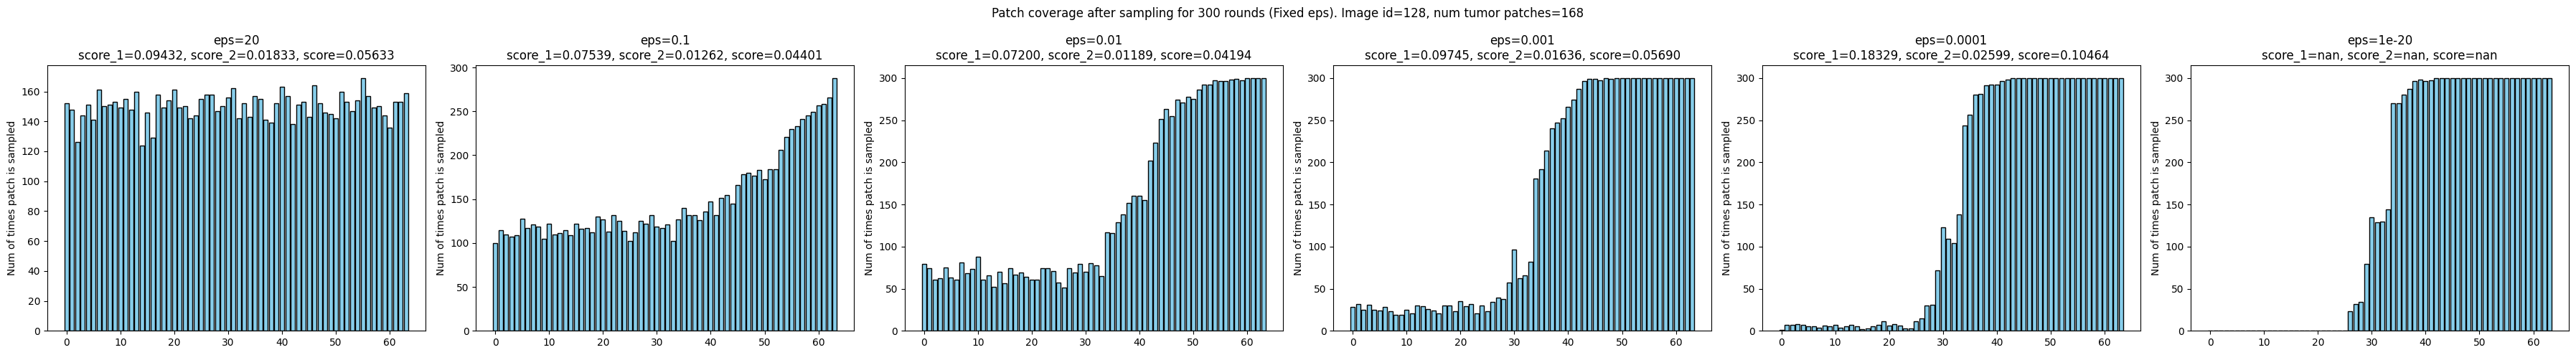

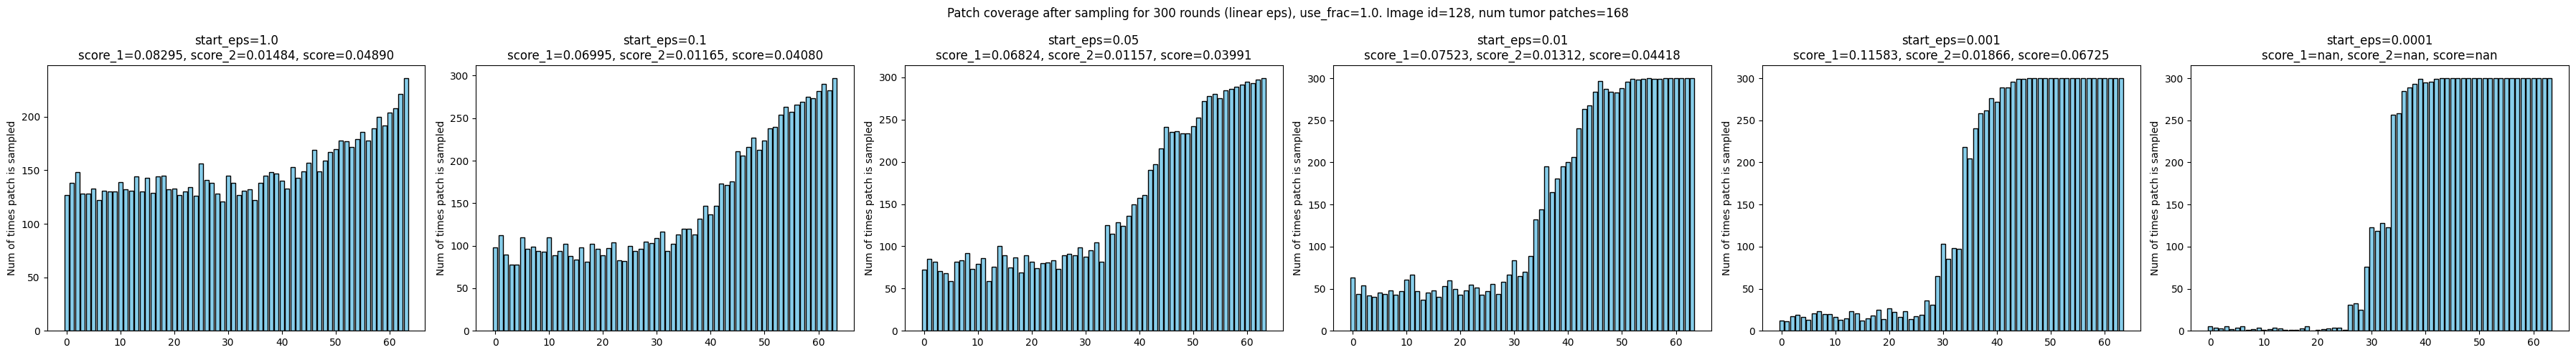

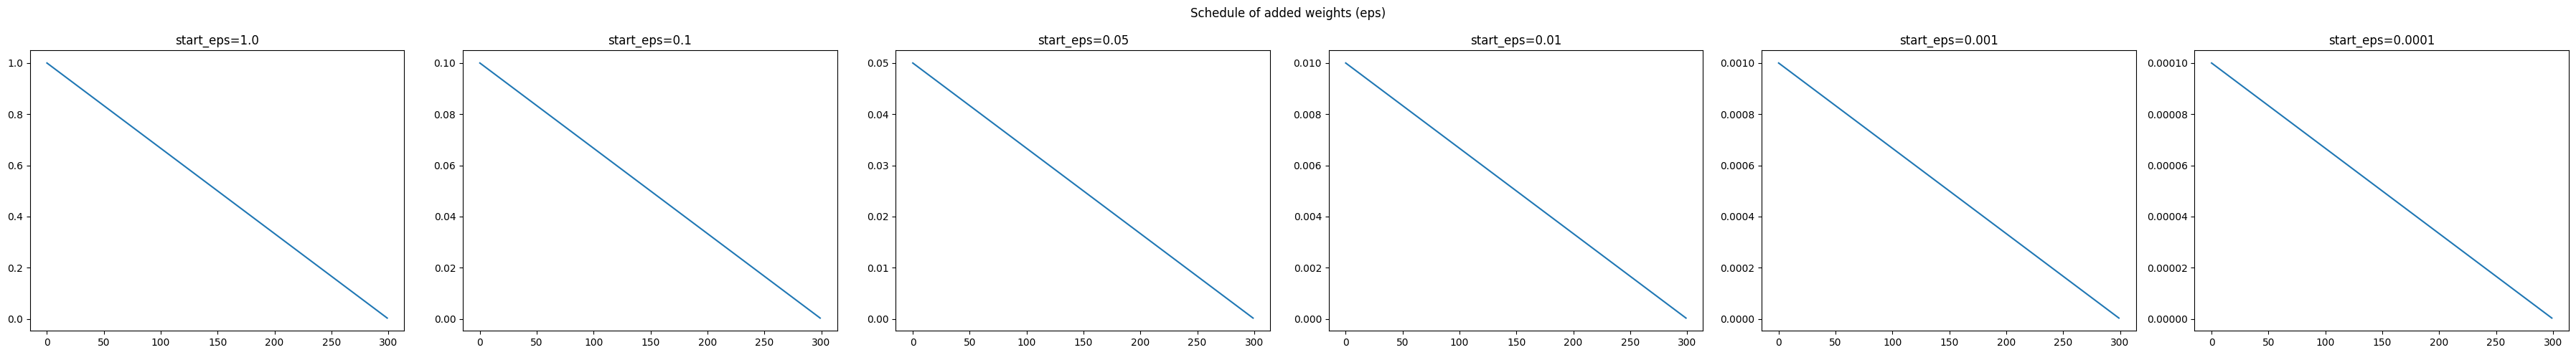

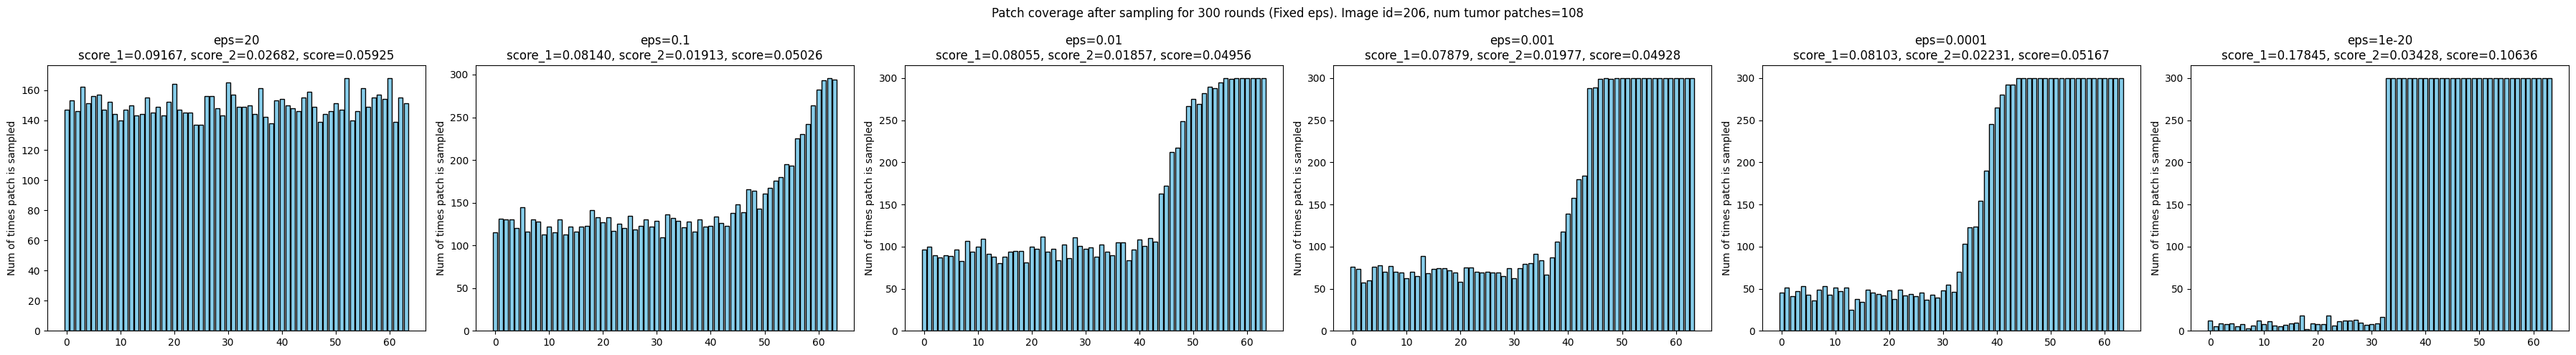

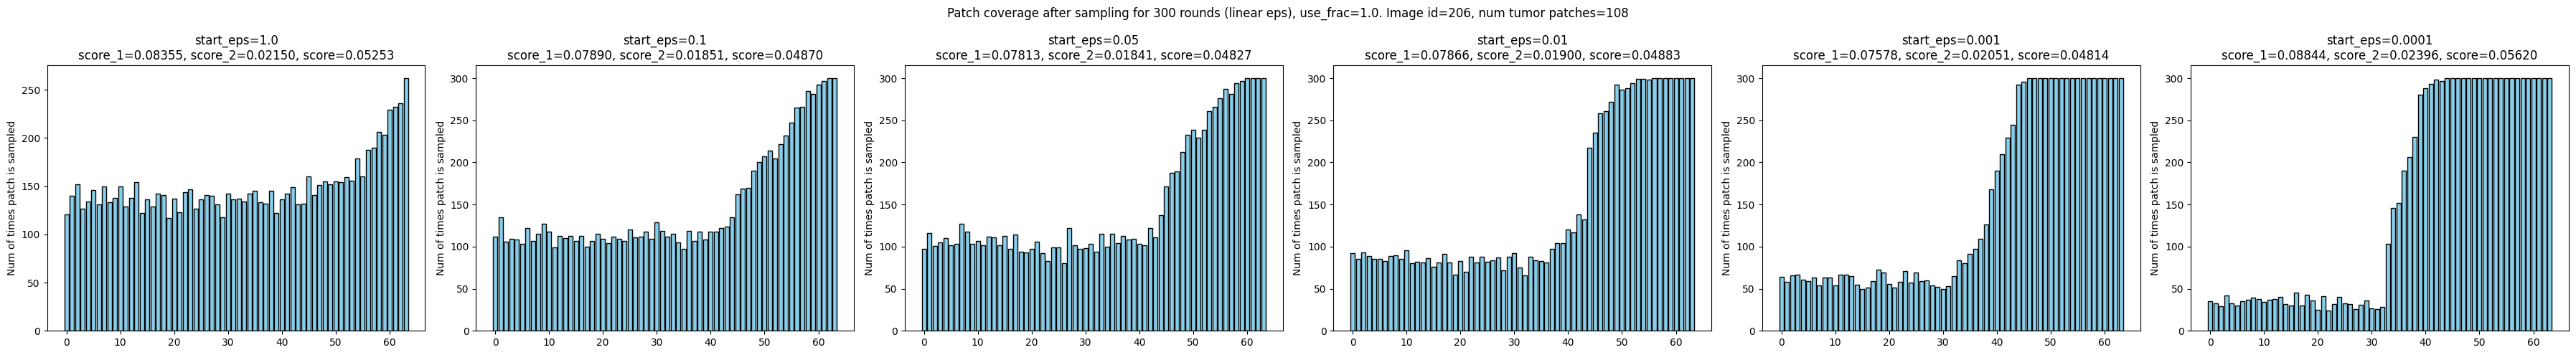

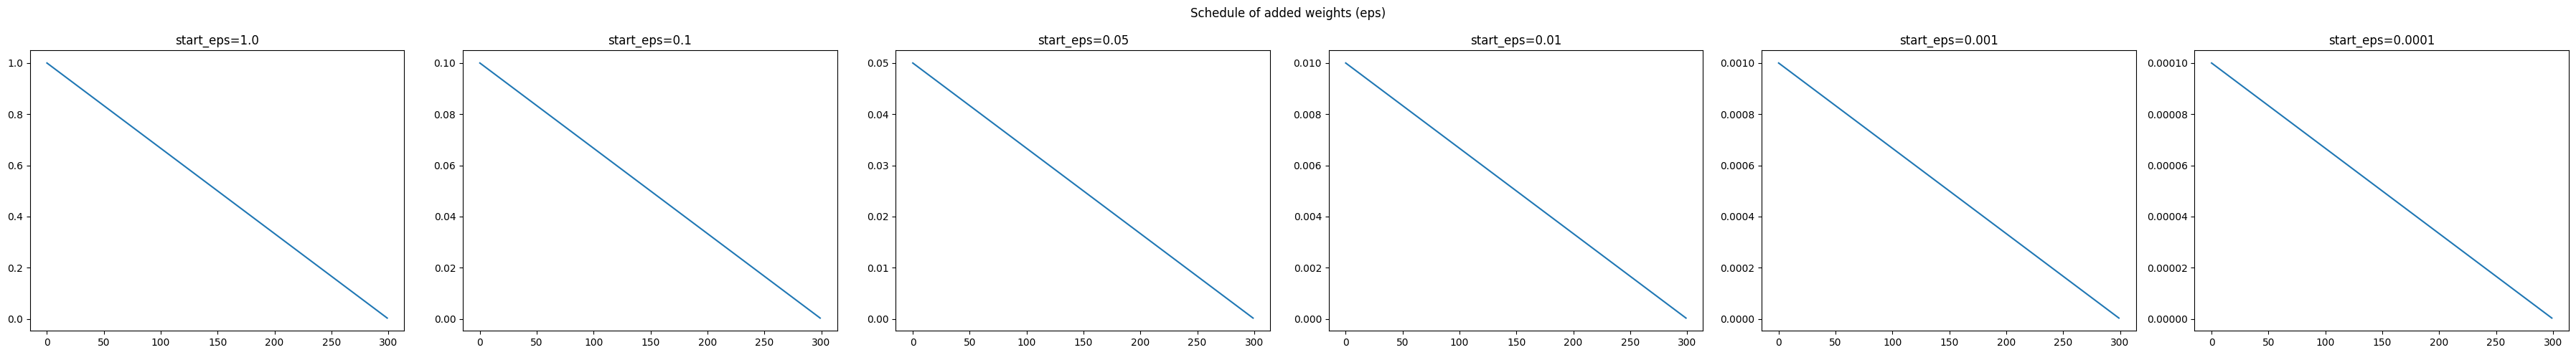

In [11]:
def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps*(1-(i/N_use))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=32  #num of patches to sample out of 64 patches

base_epss = [20,0.1,0.01,0.001,1e-4,1e-20]

use_fracs = [1.0]
schedules = ['linear']
start_epss = [1.0, 0.1,0.05,0.01,0.001,1e-4]

#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]
#for idx in range(len(val_data)):
image_idxs = [128, 206]
key = 'hist2_16'
for idx in image_idxs:
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data['hist2_16'][idx])
    num_tumor = hist_data['hist2_16'][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print(all_patch_vols.nonzero())
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    nrow, ncol = 1, len(base_epss)
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_2 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_1+kl_2)
        kl_1 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        kl_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        score_2 = kl_1+kl_2
        mean_score = 0.5*(score_1+score_2)
        ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")

    fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            nrow, ncol = 1, len(start_epss)
            fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
            fig1, ax1 = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")

            for i,start_eps in enumerate(start_epss):
                counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                counts_p = counts/counts.sum()

                kl_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                kl_2 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                score_1 = 10*(kl_1+kl_2)
                kl_1 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                kl_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                score_2 = kl_1+kl_2
                mean_score = 0.5*(score_1+score_2)

                ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")
                ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}")

            fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps), use_frac={use_frac}. Image id={idx}, num tumor patches={num_tumor}")
            fig.tight_layout()
            fig1.suptitle('Schedule of added weights (eps)')
            fig1.tight_layout()

In [211]:
np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()

[1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

Compute scores for every image and compute mean to see which *use_frac* and *start_eps* combination performs best 

Also compare between *fixed eps* and *dynamic eps* (schedule based)

In [ ]:

def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps*(1-(i/N_use))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=256  #num of patches to sample out of 64 patches

base_epss = [20,0.1,0.01,0.001,1e-4,1e-20]
use_fracs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
schedules = ['linear','cosine']
start_epss_1 = np.around(np.linspace(0.1, 0.01, 10), decimals=2).tolist()
start_epss_2 = np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()
start_epss = start_epss_1 + start_epss_2 +[0.001, 1e-4]

print(start_epss)
#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]

fixed_eps_df_rows = []
dyn_eps_df_rows = []
key = 'hist2_16'
for idx in range(len(val_data)):
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs['16'][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    #fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        fixed_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
        fixed_eps_df_row['eps'] = eps
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
    
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)

        fixed_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                        'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
        fixed_eps_df_rows.append(fixed_eps_df_row)

        #ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")

    #fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    #fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for i,start_eps in enumerate(start_epss):
                dyn_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
                dyn_eps_df_row.update({'schedule':schedule, 'use_frac':use_frac, 'start_eps':start_eps})
                
                counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                counts_p = counts/counts.sum()

                kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                score_1 = 10*(kl_wt_1+kl_uni_1)
            
                kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                score_2 = kl_wt_2+kl_uni_2
                mean_score = 0.5*(score_1+score_2)

                dyn_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                                'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
                dyn_eps_df_rows.append(dyn_eps_df_row)

                #ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")
                #ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}")

            #fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps), use_frac={use_frac}. Image id={idx}, num tumor patches={num_tumor}")
            #fig.tight_layout()
            #fig1.suptitle('Schedule of added weights (eps)')
            #fig1.tight_layout()

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')

[0.1, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01, 1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.001, 0.0001]
Processing image 0
Non-Tumor and Tumor Patch Counts [425  87]
All patches vol fracs sorted metatensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,

/home/ca550013/Miniconda3-New/envs/bratseg/lib/python3.10/site-packages/torch/nn/functional.py:2994: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Processing image 1
Non-Tumor and Tumor Patch Counts [460  52]
All patches vol fracs sorted metatensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.000

KeyboardInterrupt: 

In [214]:

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')


In [215]:
fixed_eps_df.head()

,image_id,num_tumor_patches,eps,kl_wt_1,kl_uni_1,score_1,kl_wt_2,kl_uni_2,score_2,mean_score
0,0,14,20.0000,0.001810,0.000060,0.018705,0.031375,0.000035,0.031410,0.025058
1,0,14,0.1000,0.000848,0.000632,0.014796,0.022415,0.000625,0.023040,0.018918
2,0,14,0.0100,0.000340,0.001036,0.013761,0.021512,0.001043,0.022554,0.018158
3,0,14,0.0010,0.000062,0.001558,0.016205,0.021420,0.001562,0.022982,0.019594
4,0,14,0.0001,0.000047,0.001659,0.017061,0.021415,0.001666,0.023081,0.020071


            eps   kl_wt_1  kl_uni_1   kl_wt_2  kl_uni_2   score_2  mean_score
0  1.000000e-20  0.000053       inf  0.022672       inf  0.025386    0.026567
1  1.000000e-04  0.000144       inf  0.022589       inf  0.025045    0.025554
2  1.000000e-03  0.000407  0.001982  0.022539  0.001976  0.024516    0.024204
3  1.000000e-02  0.000892  0.001274  0.022735  0.001268  0.024003    0.022831
4  1.000000e-01  0.001637  0.000503  0.024812  0.000491  0.025303    0.023351
5  2.000000e+01  0.002721  0.000052  0.033199  0.000026  0.033226    0.030477


<Axes: title={'center': 'Mean score vs eps'}, xlabel='eps'>

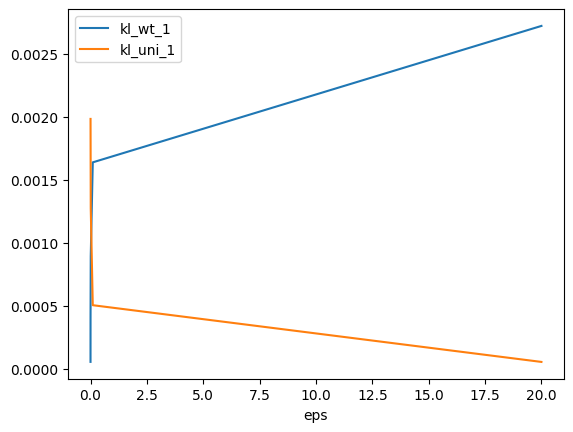

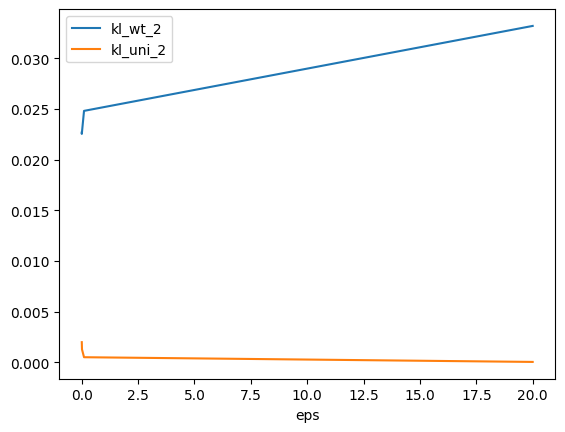

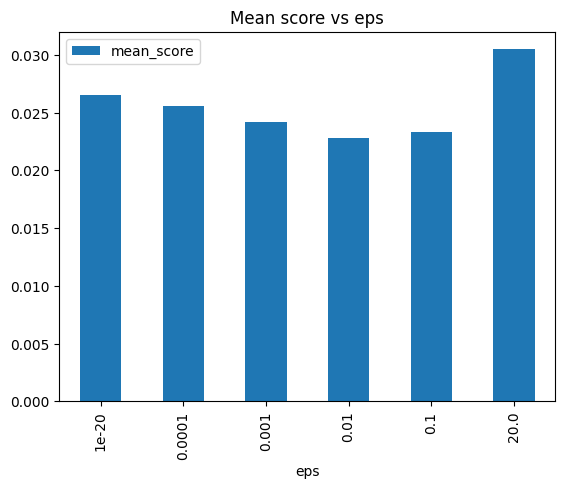

In [118]:
#find mean score for each eps 'kl_wt_2','kl_uni_2','score_2','mean_score'
fixed_eps_agg = fixed_eps_df.groupby(['eps'], as_index=False)[['kl_wt_1', 'kl_uni_1', 'kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print(fixed_eps_agg)
fixed_eps_agg[['eps', 'kl_wt_1', 'kl_uni_1']].set_index('eps').plot()
fixed_eps_agg[['eps', 'kl_wt_2', 'kl_uni_2']].set_index('eps').plot()
fixed_eps_agg[['eps', 'mean_score']].set_index('eps').plot(kind='bar', title='Mean score vs eps')


#Obs: As eps increases, patch distrbitution becomes close to uniform, so kl_uni decreases
## and if eps is small, patch distribution is more close to weighted distribution

In [86]:
dyn_eps_df

,image_id,num_tumor_patches,schedule,use_frac,start_eps,kl_wt_1,kl_uni_1,score_1,kl_wt_2,kl_uni_2,score_2,mean_score
0,0,14,linear,1.0,1.0000,0.001172,0.000261,0.014328,0.026015,0.000227,0.026242,0.020285
1,0,14,linear,1.0,0.1000,0.000656,0.000832,0.014883,0.021887,0.000789,0.022677,0.018780
2,0,14,linear,1.0,0.0900,0.000604,0.000827,0.014306,0.021789,0.000803,0.022591,0.018449
3,0,14,linear,1.0,0.0800,0.000554,0.000844,0.013974,0.021755,0.000829,0.022584,0.018279
4,0,14,linear,1.0,0.0700,0.000560,0.000852,0.014119,0.021733,0.000830,0.022563,0.018341
...,...,...,...,...,...,...,...,...,...,...,...,...
16895,259,25,linear,0.6,0.0300,0.001000,0.002415,0.034156,0.016760,0.002384,0.019145,0.026651
16896,259,25,linear,0.6,0.0200,0.000816,0.002640,0.034555,0.016703,0.002634,0.019336,0.026946
16897,259,25,linear,0.6,0.0100,0.000586,0.003040,0.036260,0.016650,0.003025,0.019674,0.027967
16898,259,25,linear,0.6,0.0010,0.000140,0.004591,0.047317,0.016597,0.004579,0.021176,0.034247


In [120]:
import seaborn as sns


min score config:       use_frac  start_eps schedule   kl_wt_1  kl_uni_1   score_1   kl_wt_2  \
151       0.6        0.2   linear  0.000857  0.000932  0.017891  0.023729   

     kl_uni_2  score_2  mean_score  
151  0.000921  0.02465     0.02127  


<Axes: xlabel='num_tumor_patches'>

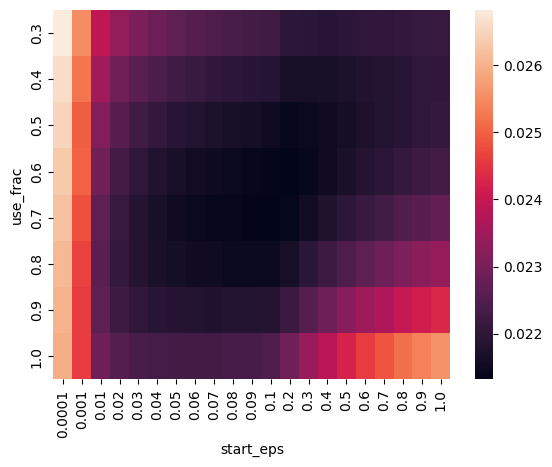

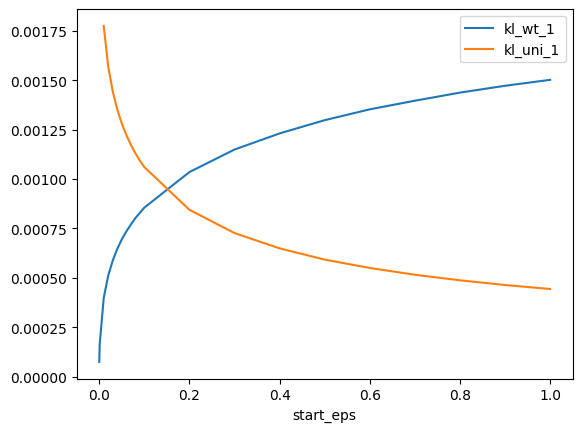

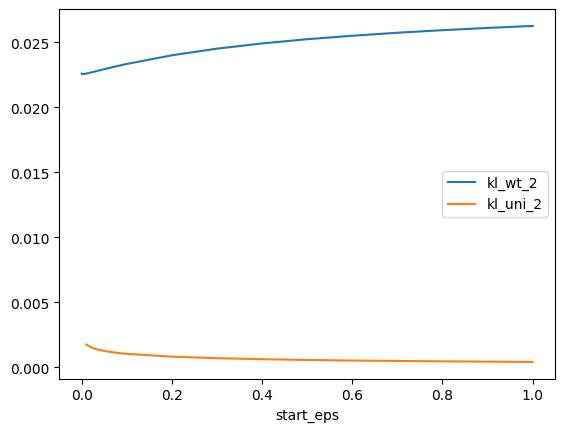

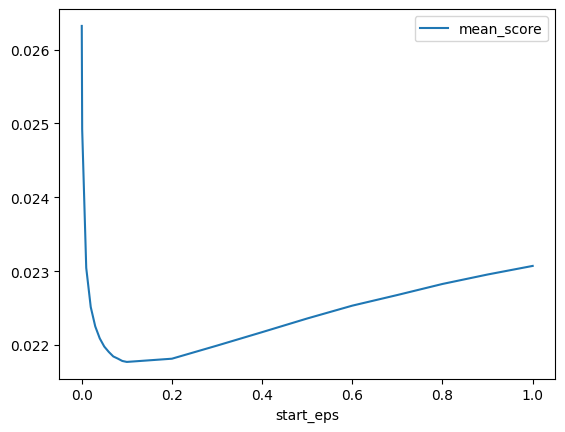

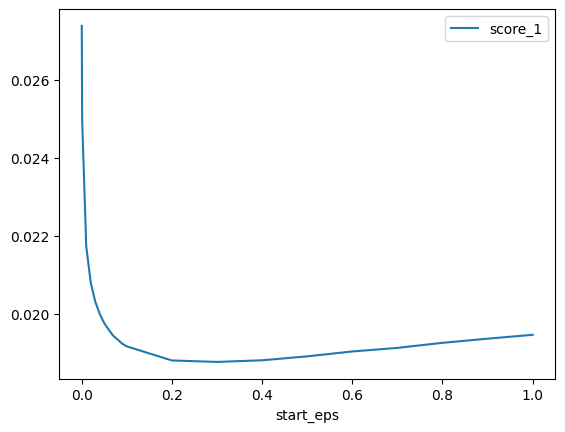

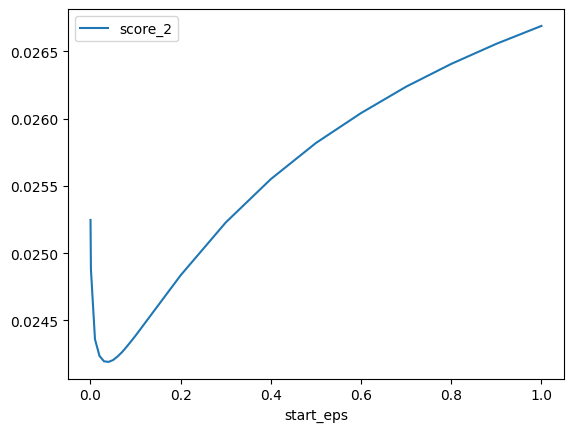

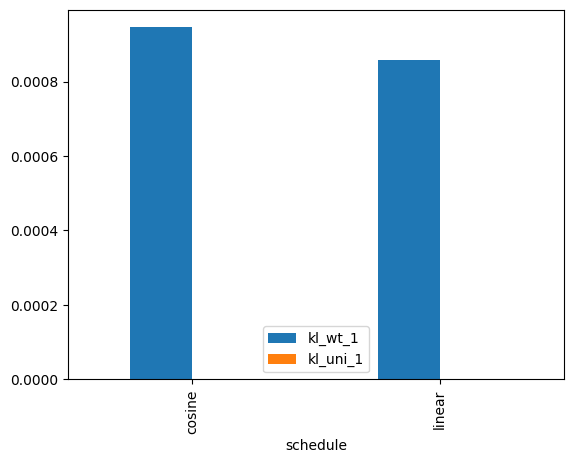

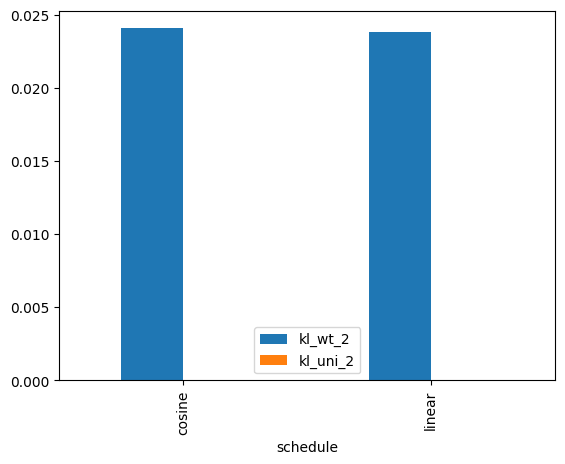

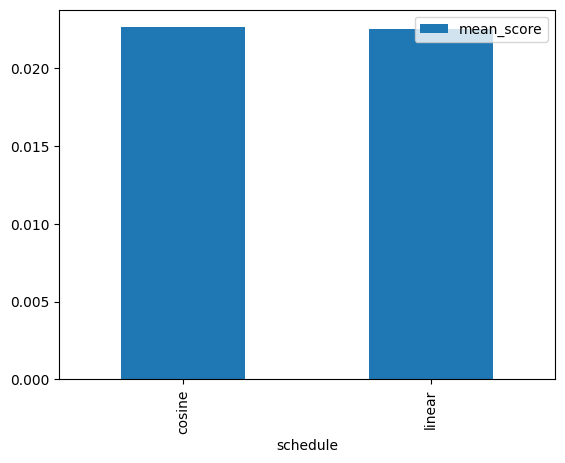

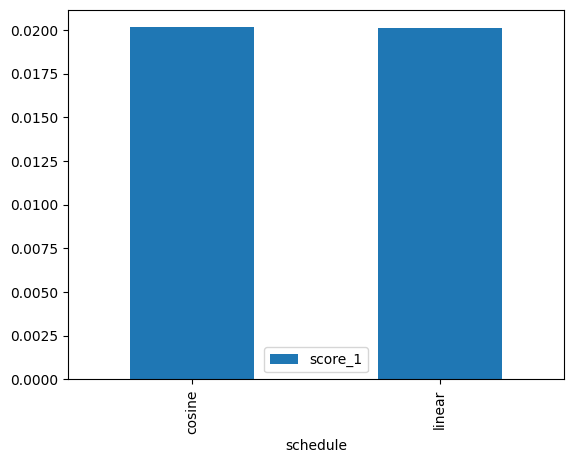

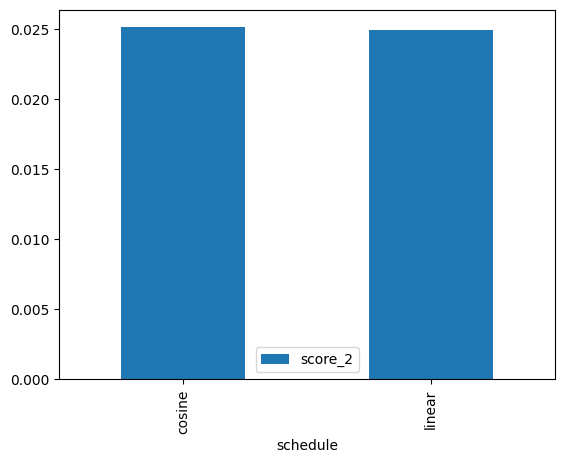

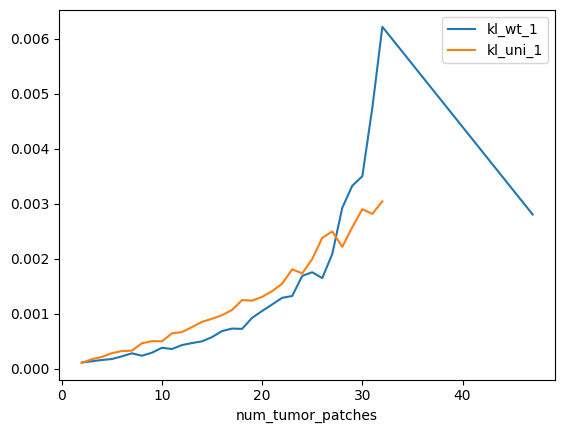

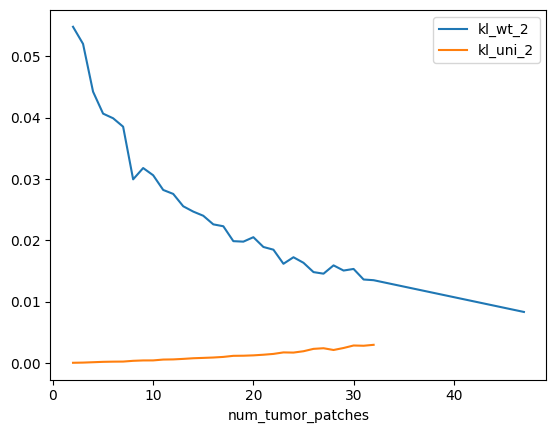

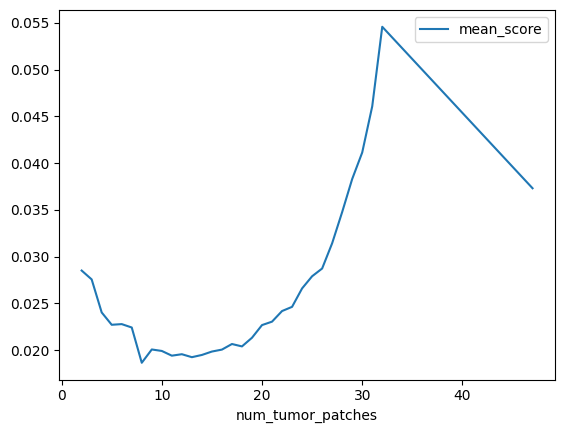

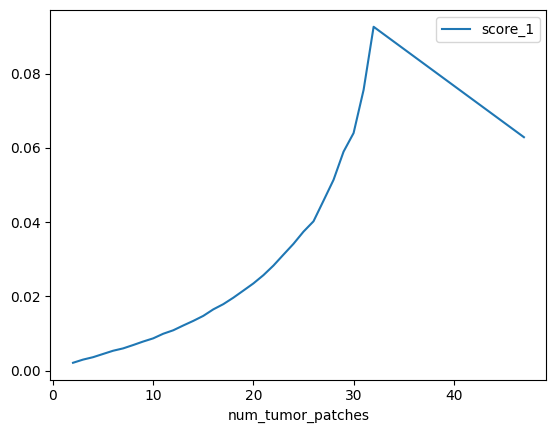

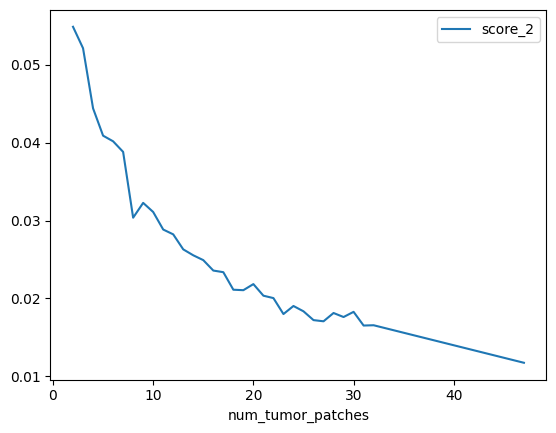

In [226]:
dyn_eps_all_agg_ = dyn_eps_df.groupby(['use_frac','start_eps','schedule'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print('min score config: ', dyn_eps_all_agg_[dyn_eps_all_agg_['mean_score'] == dyn_eps_all_agg_['mean_score'].min()])

dyn_eps_all_agg= dyn_eps_df.groupby(['use_frac','start_eps'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
sns.heatmap(dyn_eps_all_agg.pivot(index='use_frac',columns='start_eps',values='mean_score'))

dyn_eps_agg = dyn_eps_all_agg.groupby(['start_eps'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_eps_agg[['start_eps', 'kl_wt_1', 'kl_uni_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'kl_wt_2', 'kl_uni_2']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'mean_score']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_2']].set_index('start_eps').plot()

dyn_schedule_agg = dyn_eps_df.groupby(['schedule'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_schedule_agg[['schedule', 'kl_wt_1', 'kl_uni_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'kl_wt_2', 'kl_uni_2']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'mean_score']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_2']].set_index('schedule').plot(kind='bar')

'''
dyn_use_agg = dyn_eps_all_agg.groupby(['use_frac'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_use_agg[['use_frac', 'kl_wt_1', 'kl_uni_1']].set_index('use_frac').plot()
dyn_use_agg[['use_frac', 'kl_wt_2', 'kl_uni_2']].set_index('use_frac').plot()
'''
dyn_num_tumor_agg = dyn_eps_df.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()


<Axes: xlabel='num_tumor_patches'>

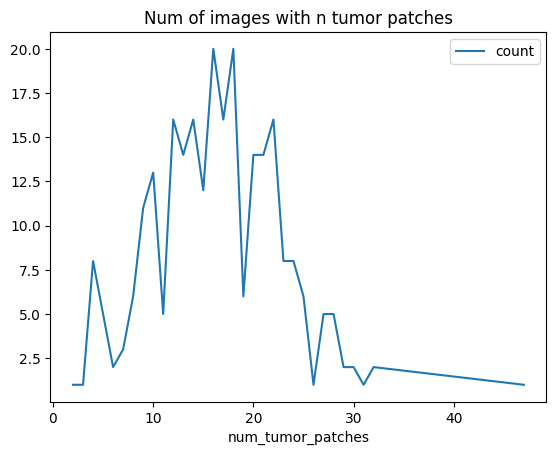

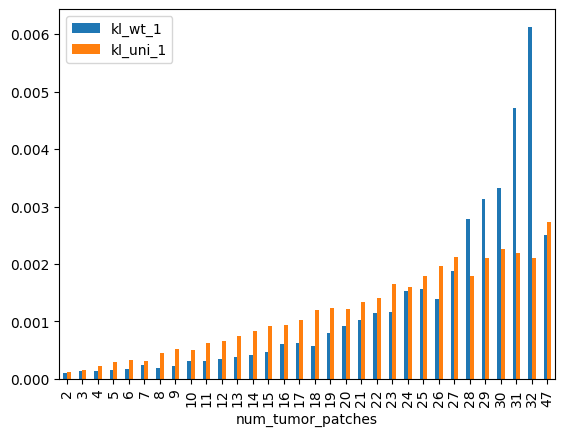

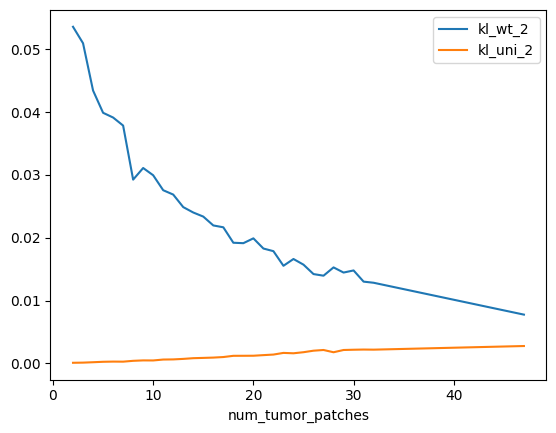

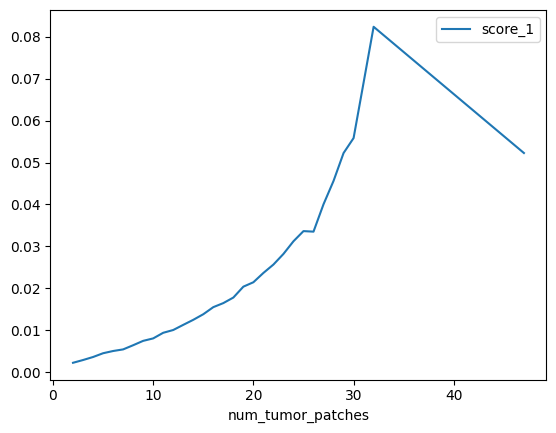

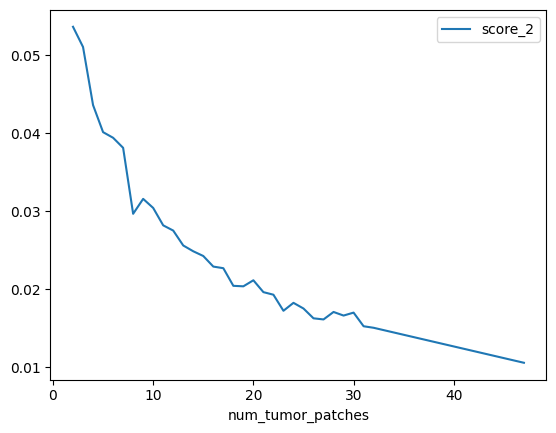

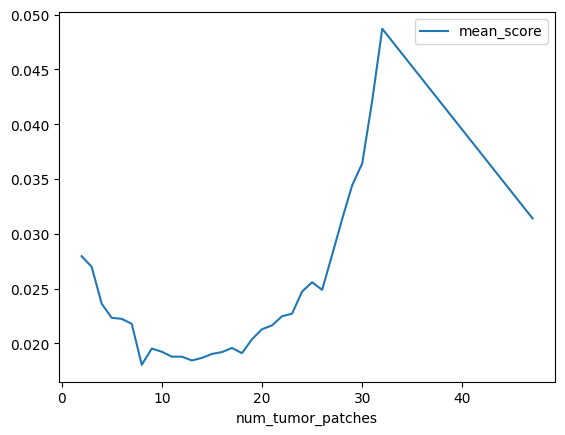

In [208]:
#Subset df on best config and plot num_tumor_patches vs scores
dyn_eps_df_sub = dyn_eps_df[(dyn_eps_df['use_frac'] == 0.7) & (dyn_eps_df['start_eps'] == 0.1)].reset_index(drop=True)
dyn_eps_df_sub_ =  dyn_eps_df_sub.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()

num_tumor_patches_counts=dyn_eps_df_sub['num_tumor_patches'].value_counts().to_frame()
dyn_eps_df_sub_ = dyn_eps_df_sub_.merge(num_tumor_patches_counts,on='num_tumor_patches')

dyn_eps_df_sub_[['num_tumor_patches', 'count']].set_index('num_tumor_patches').plot(title='Num of images with n tumor patches')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot(kind='bar')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()


Obs: Mean score is the least in for images with the most common number of patches (=15/16)

Score_1 and score_2 are very complementary in nature

kl_wt_1 is high for n_tumor_patches = 28-32 as the patch counts are compared with the *eps=1e-20* basline counts. in this case, all the 30-32 tumor patches will be sampled most of the time as we are sampling 32 items

In [33]:
dyn_eps_df.to_csv('dyn_eps_df.csv')
fixed_eps_df.to_csv('fixed_eps_df.csv')

In [10]:
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
torch.sort(all_patch_vols)

torch.return_types.sort(
values=metatensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0027, 0.0083,
         0.0085, 0.0085, 0.0151, 0.0222, 0.0310, 0.0364, 0.0401, 0.0450, 0.0522,
         0.0609, 0.0667, 0.1837, 0.2481, 0.2793, 0.4531, 0.5321, 0.6021, 0.6643,
         0.7274]]),
indices=metatensor([[45, 24, 25, 26, 27, 28, 29, 30, 31, 40, 43, 44,  1, 46, 47, 51, 55, 56,
         59, 60, 61, 62, 63, 13,  0,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
         23, 14, 20, 19, 16, 15, 39, 35, 17, 58, 42, 52, 18, 41, 21, 57, 22, 48,
         36, 32, 54, 50, 49, 53, 38, 33, 37, 34]]))

In [13]:
import itertools

def ravel_index_(index, shape):
    """Ravel multi-dimensional indices to 1D index
    similar to np.ravel_multi_index
    Args:
        index (torch.tensor): indices in reversed order dn, ..., d1, with shape (..., n)
        shape (tuple): dn, ..., d1
    """
    index = torch.tensor(index, dtype=torch.int64)
    shape = torch.tensor((1,) + shape[::-1], dtype=torch.int64) # =(1, d1, d1*d2, ..., d1*...*dn)
    shape = torch.cumprod(shape, dim=0)[:-1].flip(0) # =(d1*...*dn-1, ..., d1*d2, d1, 1)
    index = (index * shape).sum(dim=-1) # (...,)
    return index


def get_16_idx_from_32_flat_idx(flat_idxs_32,x_16_shape,x_32_shape):
  assert len(x_16_shape) == len(x_32_shape)
  print('flat_idxs_32 ', flat_idxs_32)

  unravled_idxs_32 = torch.unravel_index(flat_idxs_32, x_32_shape)
  unravled_idxs_32_T = torch.stack(unravled_idxs_32, dim=0).T
  unravled_idxs_start_16 = unravled_idxs_32_T*torch.tensor([1,2,2,2])

  list(itertools.product([0, 1], repeat=3))
  offsets = list(itertools.product([0, 1], repeat=3))
  offsets = [[0]+list(offset) for offset in offsets]
  offsets = torch.tensor(offsets)
  print('offsets ', offsets)

  unraveled_idxs_all_16 = unravled_idxs_start_16.unsqueeze(1) + offsets
  unraveled_idxs_all_16 = unraveled_idxs_all_16.contiguous().view(-1,len(x_16_shape))

  flat_idxs_16 = ravel_index_(unraveled_idxs_all_16, x_16_shape)
  print('flat_idxs_16 ', flat_idxs_16)

  unraveled_idxs_all_16 = torch.unbind(unraveled_idxs_all_16, dim=1)
  return flat_idxs_16, unraveled_idxs_all_16


x_16 = torch.linspace(0, 1023, steps=1024).view(2,8,8,8)
x_32 = torch.linspace(0, 127, steps=128).view(2,4,4,4)
sampled_idxs_32 = torch.multinomial(torch.ones_like(x_32.flatten()),num_samples=32)

flat_idxs_16, unraveled_idxs_all_16 = get_16_idx_from_32_flat_idx(sampled_idxs_32,x_16.shape,x_32.shape)
test_raveled_idxs_16 = x_16[unraveled_idxs_all_16]
assert torch.all(flat_idxs_16 == test_raveled_idxs_16)


flat_idxs_32  tensor([ 39,  10,  40,  76,  44,  70,  80, 105,  49, 109,  79,  66,  55,  50,
         98, 111,  31,  91,   8,  45,  88,  22,  11,  53,  60,  21, 124,  62,
        108, 117,  87,  20])
offsets  tensor([[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1]])
flat_idxs_16  tensor([ 278,  279,  286,  287,  342,  343,  350,  351,   36,   37,   44,   45,
         100,  101,  108,  109,  288,  289,  296,  297,  352,  353,  360,  361,
         560,  561,  568,  569,  624,  625,  632,  633,  304,  305,  312,  313,
         368,  369,  376,  377,  532,  533,  540,  541,  596,  597,  604,  605,
         640,  641,  648,  649,  704,  705,  712,  713,  802,  803,  810,  811,
         866,  867,  874,  875,  386,  387,  394,  395,  450,  451,  458,  459,
         818,  819,  826,  827,  882,  883,  890,  891,  566,  567,  574,  575,
         630,  631,  638,  639,  516,  51

/tmp/ca550013/login23-g-1_35511/ipykernel_20455/3048295669.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  index = torch.tensor(index, dtype=torch.int64)


In [14]:
patch_tumor_vol_fracs['16'][idx].shape

torch.Size([1, 8, 8, 8])

Tumor Patch indices metatensor([468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481,
        482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495,
        496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509,
        510, 511])
flat_idxs_32  metatensor([44,  6, 57, 31, 35, 25, 11, 23, 56, 16, 41, 12, 34, 53, 58, 33, 60,  7,
        17, 62, 24, 61, 40, 48, 39, 63,  8, 51, 52, 46, 55, 37])
offsets  tensor([[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1]])
flat_idxs_16  tensor([304, 305, 312, 313, 368, 369, 376, 377,  20,  21,  28,  29,  84,  85,
         92,  93, 418, 419, 426, 427, 482, 483, 490, 491, 182, 183, 190, 191,
        246, 247, 254, 255, 262, 263, 270, 271, 326, 327, 334, 335, 162, 163,
        170, 171, 226, 227, 234, 235,  38,  39,  46,  47, 102, 103, 110, 111,
        150, 151, 158, 159, 214, 215, 222, 223, 

/tmp/ca550013/login23-g-1_35511/ipykernel_20455/3048295669.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  index = torch.tensor(index, dtype=torch.int64)


flat_idxs_32  metatensor([59, 57, 43, 53, 61, 45, 10, 35, 56, 24, 52, 44, 26, 47, 54,  7, 27,  8,
        33, 37,  3, 41, 58,  0, 50, 49,  5,  9, 63, 16,  2, 31])
offsets  tensor([[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1]])
flat_idxs_16  tensor([422, 423, 430, 431, 486, 487, 494, 495, 418, 419, 426, 427, 482, 483,
        490, 491, 294, 295, 302, 303, 358, 359, 366, 367, 402, 403, 410, 411,
        466, 467, 474, 475, 434, 435, 442, 443, 498, 499, 506, 507, 306, 307,
        314, 315, 370, 371, 378, 379,  36,  37,  44,  45, 100, 101, 108, 109,
        262, 263, 270, 271, 326, 327, 334, 335, 416, 417, 424, 425, 480, 481,
        488, 489, 160, 161, 168, 169, 224, 225, 232, 233, 400, 401, 408, 409,
        464, 465, 472, 473, 304, 305, 312, 313, 368, 369, 376, 377, 164, 165,
        172, 173, 228, 229, 236, 237, 310, 311, 318, 319, 374, 375, 382, 383,
        404, 

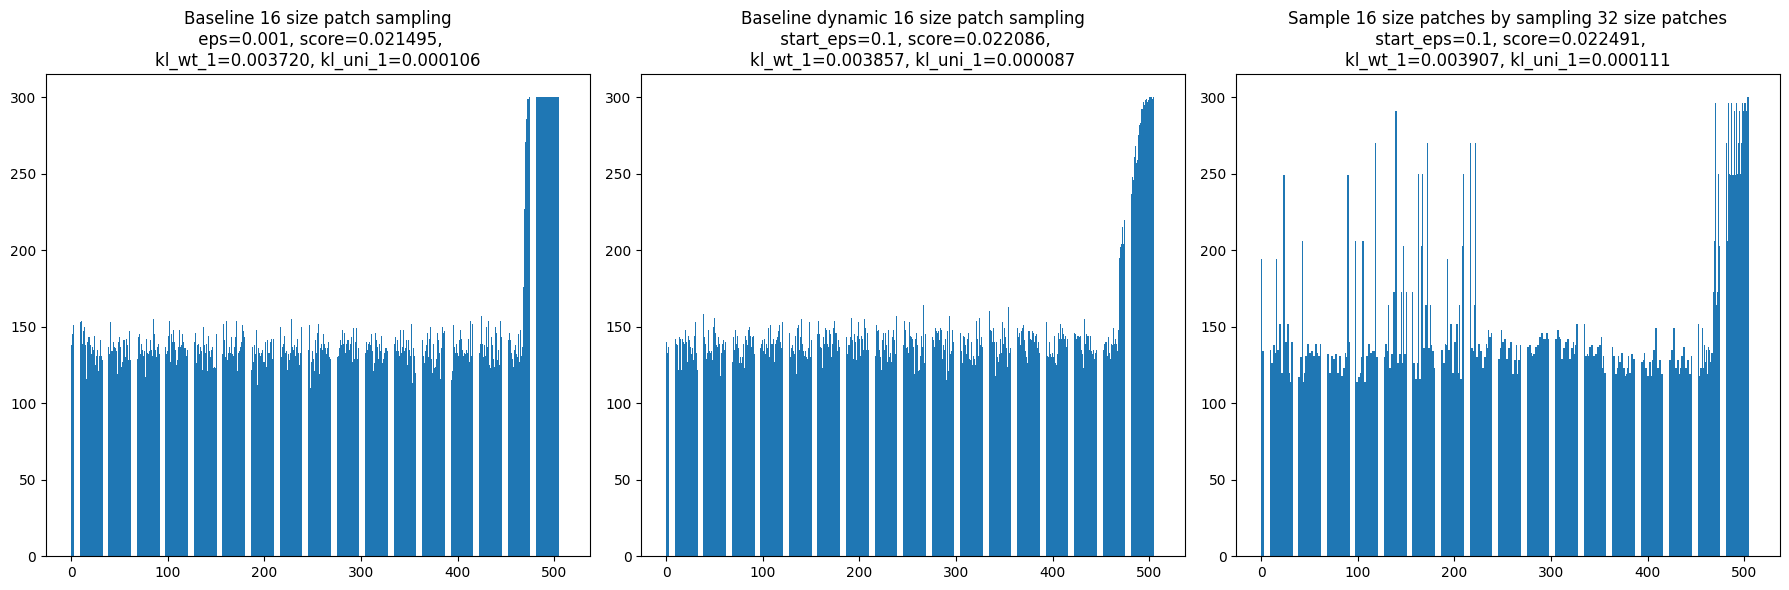

In [48]:

idx = 34
N=300
k_32 = 32
k_16 = 256
eps= 0.001
all_patch_vols_16 = patch_tumor_vol_fracs['16'][idx].view(1,-1).squeeze(dim=0)
all_patch_vols_16_sorted_out=torch.sort(all_patch_vols_16)
all_patch_vols_16_sorted = all_patch_vols_16_sorted_out.values
sorted_indices_16 = all_patch_vols_16_sorted_out.indices
idx_mapping = torch.argsort(sorted_indices_16)
print('Tumor Patch indices' ,all_patch_vols_16_sorted.nonzero()[:,0])

cmp_counts_weighted = count_samples(all_patch_vols_16_sorted,eps=1e-20,k=k,N=N)
cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
cmp_counts_uniform = count_samples(all_patch_vols_16_sorted,eps=20,k=k,N=N)
cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()
uniform_wts = torch.ones_like(all_patch_vols_16_sorted)/len(all_patch_vols_16_sorted)
tumor_wts = all_patch_vols_16_sorted/all_patch_vols_16_sorted.sum()


fig, axs = plt.subplots(1,3,figsize=(18,6))

counts_16_base = count_samples(all_patch_vols_16_sorted,eps=eps,k=k_16,N=N)
counts_16_base_p = counts_16_base/counts_16_base.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base = 0.5*(score_1+score_2)

axs[0].bar(range(len(counts_16_base)),counts_16_base)
axs[0].set_title(f"Baseline 16 size patch sampling\n eps={eps}, score={mean_score_base:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

use_frac=0.7
start_eps=0.1
schedule='linear'

counts_16_base_dyn, _ = count_samples_dyn_eps(all_patch_vols_16_sorted,start_eps=start_eps,\
                schedule=schedule,k=k_16,N=N,use_frac=use_frac)
counts_16_base_dyn_p = counts_16_base_dyn/counts_16_base_dyn.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base_dyn = 0.5*(score_1+score_2)
axs[1].bar(range(len(counts_16_base_dyn)),counts_16_base_dyn)
axs[1].set_title(f"Baseline dynamic 16 size patch sampling\n start_eps={start_eps}, score={mean_score_base_dyn:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

#sample constitiuent 16 size patches from randonly chosen 32 size patches
all_patch_vols_32 = patch_tumor_vol_fracs['32'][idx].view(1,-1).squeeze(dim=0)
counts_16_from_32 = torch.zeros_like(all_patch_vols_16)
for i in range(N):
  N_use = N*use_frac
  if i <= N_use - 1:
      if schedule == 'linear':
          eps = start_eps*(1-(i/N_use))
      elif schedule == 'cosine':
          eps = start_eps*np.cos((np.pi*i)/(2*N_use))

  #directly sample 16 patches
  if 1==0:
    sampled_idxs_16_base_dyn = torch.multinomial(all_patch_vols_16_sorted+eps, num_samples=k_16)
    counts_16_from_32[sampled_idxs_16_base_dyn] +=1

  #16 from 32
  else:
    sampled_idxs_32 = torch.multinomial(all_patch_vols_32+eps, num_samples=k_32)
    sampled_idxs_16_from_32, _ = get_16_idx_from_32_flat_idx(sampled_idxs_32,patch_tumor_vol_fracs['16'][idx].shape,patch_tumor_vol_fracs['32'][idx].shape)
    counts_16_from_32[idx_mapping[sampled_idxs_16_from_32]] +=1

counts_16_from_32_p = counts_16_from_32/counts_16_from_32.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_16_from_32 = 0.5*(score_1+score_2)


axs[2].bar(range(len(counts_16_from_32)),counts_16_from_32)
axs[2].set_title(f"Sample 16 size patches by sampling 32 size patches\n start_eps={start_eps}, score={mean_score_16_from_32:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

fig.tight_layout()

In [24]:
counts_16_base_dyn

metatensor([ 401.,  380.,  374.,  400.,  399.,  418.,  413.,  376.,  388.,  397.,
         394.,  393.,  377.,  364.,  390.,  366.,  362.,  383.,  384.,  398.,
         406.,  395.,  395.,  412.,  390.,  404.,  401.,  410.,  369.,  396.,
         407.,  400.,  397.,  380.,  391.,  386.,  384.,  393.,  377.,  394.,
         391.,  383.,  375.,  388.,  389.,  367.,  332.,  399.,  389.,  390.,
         380.,  372.,  400.,  391.,  415.,  397.,  405.,  385.,  393.,  401.,
         406.,  421.,  374.,  377.,  402.,  381.,  383.,  361.,  415.,  382.,
         387.,  399.,  396.,  379.,  387.,  370.,  401.,  416.,  407.,  373.,
         422.,  395.,  378.,  392.,  384.,  364.,  423.,  393.,  390.,  401.,
         377.,  376.,  395.,  405.,  395.,  400.,  374.,  391.,  370.,  421.,
         369.,  397.,  382.,  375.,  392.,  390.,  415.,  411.,  413.,  413.,
         350.,  382.,  372.,  381.,  384.,  398.,  384.,  399.,  401.,  384.,
         404.,  390.,  380.,  377.,  380.,  397.,  376.,  37

In [25]:
counts_16_from_32

metatensor([573., 251., 603., 603., 375., 375., 275., 275., 573., 573., 923., 250.,
        250., 275., 275., 251., 250., 250., 275., 275., 611., 611., 372., 372.,
        275., 275., 611., 611., 372., 685., 250., 275., 275., 611., 611., 372.,
        372., 275., 275., 611., 372., 282., 282., 372., 708., 282., 282., 685.,
        708., 263., 263., 251., 251., 603., 375., 263., 263., 269., 267., 267.,
        677., 677., 269., 269., 248., 248., 267., 267., 677., 677., 269., 248.,
        274., 274., 555., 555., 677., 677., 295., 295., 274., 274., 555., 555.,
        677., 251., 282., 282., 685., 708., 708., 282., 282., 685., 708., 708.,
        263., 263., 251., 250., 603., 603., 375., 375., 263., 263., 251., 251.,
        603., 603., 375., 297., 248., 280., 281., 281., 279., 279., 605., 605.,
        777., 777., 279., 279., 605., 605., 777., 777., 251., 280., 265., 265.,
        307., 307., 280., 280., 265., 265., 746., 746., 307., 307., 706., 265.,
        265., 268., 268., 706., 706.